In [1]:
import pathlib
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_DIRECTORY = pathlib.Path().resolve() / "Data_Project"

### In the first part of the task, we have estimated the population density of each RegSO. In this spatial data analysis, we will calculate the **footprint of different building types** by **RegSO**.
### For this spatial analysis, data available at Geotorget is analysed. In this case, **Byggnad Nedladdning, vektor** dataset is procured from https://geotorget.lantmateriet.se/geodataprodukter/byggnad-nedladdning-vektor-api. These datasets are available for researchers upon request to **Lantmäteriet**.
### In this case, building data for Kommun **Göteborg** with Kommunkod **1480** has been utilized.

In [3]:
buildings_data = gpd.read_file(DATA_DIRECTORY / "byggnad_kn1480.gpkg")

<Axes: >

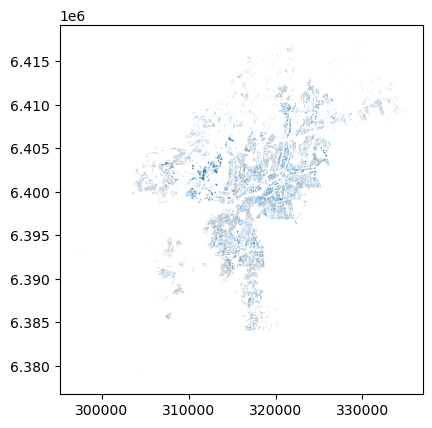

In [4]:
buildings_data.plot()

In [5]:
buildings_data.head()

,objektidentitet,versiongiltigfran,lagesosakerhetplan,lagesosakerhethojd,ursprunglig_organisation,objektversion,objekttypnr,objekttyp,insamlingslage,byggnadsnamn1,byggnadsnamn2,byggnadsnamn3,husnummer,huvudbyggnad,andamal1,andamal2,andamal3,andamal4,andamal5,geometry
0,b3d3ce9f-017f-4e9a-bf86-b23b8cb87162,2017-12-04 14:36:26.106000+00:00,0.050,NaN,Göteborg,2,2066,Komplementbyggnad,Fasad,None,None,None,2.0,Nej,Komplementbyggnad;,None,None,None,None,"MULTIPOLYGON (((317517.978 6391478.441, 317517..."
1,406f18b4-06ac-434e-aa2e-6d0c401a755a,2011-03-23 09:09:40.343000+00:00,0.025,2.5,Lantmäteriet,1,2066,Komplementbyggnad,Takkant,None,None,None,5.0,Nej,Komplementbyggnad;,None,None,None,None,"MULTIPOLYGON (((320625.83 6404492.515, 320647...."
2,406f18b4-06ac-434e-aa2e-6d0c401a755a,2011-03-23 09:09:40.343000+00:00,0.025,2.5,Lantmäteriet,1,2066,Komplementbyggnad,Fasad,None,None,None,5.0,Nej,Komplementbyggnad;,None,None,None,None,"MULTIPOLYGON (((320627.227 6404492.218, 320627..."
3,bd09f0d3-af41-4ea9-906b-13453fb26842,2024-04-15 12:04:24.403000+00:00,0.100,NaN,Kommunsamverkan,5,2061,Bostad,Takkant,None,None,None,4.0,Nej,Bostad;Småhus med flera lägenheter,None,None,None,None,"MULTIPOLYGON (((316778.885 6388398.221, 316780..."
4,bd09f0d3-af41-4ea9-906b-13453fb26842,2024-04-15 12:04:24.403000+00:00,0.100,NaN,Kommunsamverkan,5,2061,Bostad,Takkant,None,None,None,4.0,Nej,Bostad;Småhus med flera lägenheter,None,None,None,None,"MULTIPOLYGON (((316770.171 6388405.939, 316762..."


### Additionally, the geodataframe regso_got is imported, as the building's footprint will be added to the dataset.

In [6]:
regso_got = gpd.read_file(DATA_DIRECTORY / "regso_got.gpkg")
regso_got.head()

,objectid,regsokod,regsonamn,kommunkod,kommunnamn,urban_area,Population_2023,Pop_Density,geometry
0,545,1480R050,Hjällbo östra,1480,Göteborg,0.605145,1963,3243.850327,"POLYGON ((323472.297 6407681.235, 323511.152 6..."
1,546,1480R051,Hovås,1480,Göteborg,2.865952,3608,1258.918454,"POLYGON ((318974.816 6391538.521, 319414.27 63..."
2,2164,1480R116,Rambergsstaden östra,1480,Göteborg,0.143467,2837,19774.554674,"POLYGON ((318376.094 6401516.69, 318378.518 64..."
3,891,1480R055,Högsbotorp västra,1480,Göteborg,0.447044,4490,10043.743878,"POLYGON ((316899.568 6396772.106, 316965.881 6..."
4,2151,1480R099,Majorna Gråberget,1480,Göteborg,0.363313,4344,11956.631289,"POLYGON ((316544.428 6398740.815, 316559.212 6..."


### Within the buildings data, different unique building types need to be first extracted.

In [7]:
print(buildings_data["objekttyp"].unique())

['Komplementbyggnad' 'Bostad' 'Övrig byggnad' 'Industri'
 'Samhällsfunktion' 'Verksamhet' 'Ekonomibyggnad']


In [8]:
buildings_data.loc[buildings_data["objekttyp"] == "Bostad", "andamal1"].unique()

array(['Bostad;Småhus med flera lägenheter', 'Bostad;Småhus friliggande',
       'Bostad;Småhus radhus', 'Bostad;Flerfamiljshus',
       'Bostad;Småhus kedjehus'], dtype=object)

In [9]:
#Before combining buildings data with Regso data, it is important to check its CRS
buildings_data.crs

<Projected CRS: EPSG:3006>
Name: SWEREF99 TM
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Sweden - onshore and offshore.
- bounds: (10.03, 54.96, 24.17, 69.07)
Coordinate Operation:
- name: SWEREF99 TM
- method: Transverse Mercator
Datum: SWEREF99
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

### In this analysis, we are calculating the footprint for housing, hence the building type **"Bostad"** will be selected. Different object types are identified above.

In [10]:
res_buildings_data = buildings_data[buildings_data["objekttyp"] == "Bostad"]
res_buildings_data.head()

,objektidentitet,versiongiltigfran,lagesosakerhetplan,lagesosakerhethojd,ursprunglig_organisation,objektversion,objekttypnr,objekttyp,insamlingslage,byggnadsnamn1,byggnadsnamn2,byggnadsnamn3,husnummer,huvudbyggnad,andamal1,andamal2,andamal3,andamal4,andamal5,geometry
3,bd09f0d3-af41-4ea9-906b-13453fb26842,2024-04-15 12:04:24.403000+00:00,0.10,NaN,Kommunsamverkan,5,2061,Bostad,Takkant,None,None,None,4.0,Nej,Bostad;Småhus med flera lägenheter,None,None,None,None,"MULTIPOLYGON (((316778.885 6388398.221, 316780..."
4,bd09f0d3-af41-4ea9-906b-13453fb26842,2024-04-15 12:04:24.403000+00:00,0.10,NaN,Kommunsamverkan,5,2061,Bostad,Takkant,None,None,None,4.0,Nej,Bostad;Småhus med flera lägenheter,None,None,None,None,"MULTIPOLYGON (((316770.171 6388405.939, 316762..."
5,f0b58eee-5754-4cb9-8e33-127217f560be,2011-03-23 08:57:18.240000+00:00,0.06,2.5,Lantmäteriet,1,2061,Bostad,Takkant,None,None,None,8.0,Nej,Bostad;Småhus med flera lägenheter,None,None,None,None,"MULTIPOLYGON (((317440.546 6405350.601, 317441..."
6,bc19b913-ad21-4fa8-8903-c4f6254fb973,2011-03-23 08:57:18.240000+00:00,0.06,2.5,Lantmäteriet,1,2061,Bostad,Takkant,None,None,None,1.0,Nej,Bostad;Småhus friliggande,None,None,None,None,"MULTIPOLYGON (((324494.389 6403144.93, 324495...."
13,b9d06146-b0ba-4892-9ca1-33d7e07fbb8f,2011-03-23 09:09:40.343000+00:00,0.06,2.5,Lantmäteriet,1,2061,Bostad,Takkant,None,None,None,1.0,Nej,Bostad;Småhus friliggande,None,None,None,None,"MULTIPOLYGON (((319858.599 6405129.301, 319867..."


### We use the Overlay analysis method to get #residential buildings by regso, using the overlay operation **intersection**. This gives us the residential buildings by RegSO.

In [11]:
res_buildings_by_regso = regso_got.overlay(res_buildings_data, how="intersection")

In [12]:
res_buildings_by_regso.head()

,objectid,regsokod,regsonamn,kommunkod,kommunnamn,urban_area,Population_2023,Pop_Density,objektidentitet,versiongiltigfran,...,byggnadsnamn2,byggnadsnamn3,husnummer,huvudbyggnad,andamal1,andamal2,andamal3,andamal4,andamal5,geometry
0,545,1480R050,Hjällbo östra,1480,Göteborg,0.605145,1963,3243.850327,08eed546-2170-4f7e-83e1-24d5684f8d61,2011-03-23 09:09:40.343000+00:00,...,None,None,1.0,Nej,Bostad;Småhus friliggande,None,None,None,None,"POLYGON ((323509.578 6406815.494, 323510.859 6..."
1,545,1480R050,Hjällbo östra,1480,Göteborg,0.605145,1963,3243.850327,91e2b55c-856b-4a04-95a8-6ac812247e98,2011-03-23 08:54:14.892000+00:00,...,None,None,1.0,Nej,Bostad;Småhus friliggande,None,None,None,None,"POLYGON ((323510.016 6406999.613, 323508.689 6..."
2,545,1480R050,Hjällbo östra,1480,Göteborg,0.605145,1963,3243.850327,2ce236e3-cc46-4e7c-bf80-fce84c7e89df,2011-03-23 08:35:40.620000+00:00,...,None,None,22.0,Nej,Bostad;Flerfamiljshus,None,None,None,None,"POLYGON ((323124.091 6407186.731, 323169.824 6..."
3,545,1480R050,Hjällbo östra,1480,Göteborg,0.605145,1963,3243.850327,1d9ca2b4-0a44-4156-8169-404bcd050128,2011-03-23 08:47:03.858000+00:00,...,None,None,1.0,Nej,Bostad;Småhus friliggande,None,None,None,None,"POLYGON ((323391.237 6407009.718, 323387.06 64..."
4,545,1480R050,Hjällbo östra,1480,Göteborg,0.605145,1963,3243.850327,5b1047c8-ab29-488d-a115-e841094d1d89,2011-03-23 09:02:42.136000+00:00,...,None,None,1.0,Nej,Bostad;Småhus friliggande,None,None,None,None,"POLYGON ((323552.31 6406994.022, 323560.806 64..."


In [14]:
print(res_buildings_by_regso)

       objectid  regsokod      regsonamn kommunkod kommunnamn  urban_area  \
0           545  1480R050  Hjällbo östra      1480   Göteborg    0.605145   
1           545  1480R050  Hjällbo östra      1480   Göteborg    0.605145   
2           545  1480R050  Hjällbo östra      1480   Göteborg    0.605145   
3           545  1480R050  Hjällbo östra      1480   Göteborg    0.605145   
4           545  1480R050  Hjällbo östra      1480   Göteborg    0.605145   
...         ...       ...            ...       ...        ...         ...   
74913      2195  1480R147         Överås      1480   Göteborg    0.827124   
74914      2195  1480R147         Överås      1480   Göteborg    0.827124   
74915      2195  1480R147         Överås      1480   Göteborg    0.827124   
74916      2195  1480R147         Överås      1480   Göteborg    0.827124   
74917      2195  1480R147         Överås      1480   Göteborg    0.827124   

       Population_2023  Pop_Density                       objektidentitet  

### Here, we have dataset with **74918** buildings. Now in the next steps we will calculate the footprint for different residential buildings by each RegSO.

In [13]:
#Cleaner version of the plot without unnecessary columns
res_buildings_by_regso = res_buildings_by_regso[["regsokod", "regsonamn", "kommunkod", "husnummer", "andamal1", "geometry"]]
res_buildings_by_regso.head()

,regsokod,regsonamn,kommunkod,husnummer,andamal1,geometry
0,1480R050,Hjällbo östra,1480,1.0,Bostad;Småhus friliggande,"POLYGON ((323509.578 6406815.494, 323510.859 6..."
1,1480R050,Hjällbo östra,1480,1.0,Bostad;Småhus friliggande,"POLYGON ((323510.016 6406999.613, 323508.689 6..."
2,1480R050,Hjällbo östra,1480,22.0,Bostad;Flerfamiljshus,"POLYGON ((323124.091 6407186.731, 323169.824 6..."
3,1480R050,Hjällbo östra,1480,1.0,Bostad;Småhus friliggande,"POLYGON ((323391.237 6407009.718, 323387.06 64..."
4,1480R050,Hjällbo östra,1480,1.0,Bostad;Småhus friliggande,"POLYGON ((323552.31 6406994.022, 323560.806 64..."


In [14]:
res_buildings_by_regso.to_file(DATA_DIRECTORY / "res_buildings_by_regso.gpkg")

<Axes: >

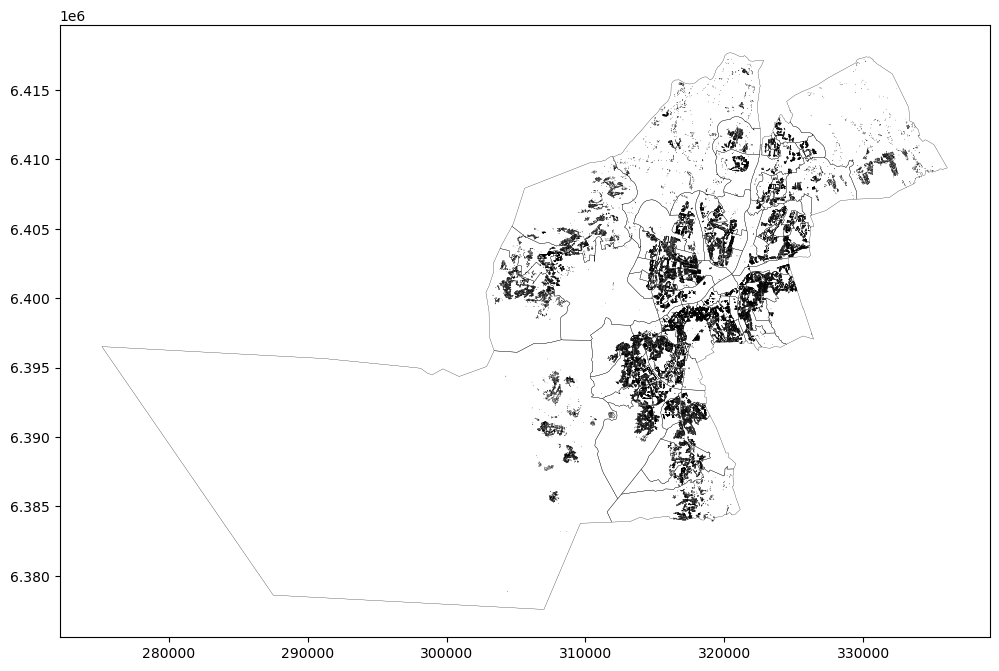

In [15]:
#Plotting multiple map layers
axes = regso_got.plot(
    figsize=(12, 8),
        edgecolor ="black", linewidth = 0.2,
        facecolor ="none"
)
res_buildings_by_regso.plot(ax=axes, facecolor="black", edgecolor = "black", linewidth = 0.3, alpha = 1)

In [16]:
#Count the number of occurances of each building type within each regsokod
Building_type_by_Regso = res_buildings_by_regso.pivot_table(
    index='regsokod',
    columns='andamal1',
    aggfunc='size',
    fill_value=0
).reset_index()

# Optional: rename columns for clarity
Building_type_by_Regso.columns.name = None  # remove the 'andamal1' label from columns

print(Building_type_by_Regso)

     regsokod  Bostad;Flerfamiljshus  Bostad;Småhus friliggande  \
0    1480R001                    178                        244   
1    1480R002                     88                        107   
2    1480R003                     83                        441   
3    1480R004                     36                       1909   
4    1480R005                     86                         40   
..        ...                    ...                        ...   
142  1480R143                     40                       1335   
143  1480R144                    161                          0   
144  1480R145                     24                         84   
145  1480R146                     34                        584   
146  1480R147                     44                        318   

     Bostad;Småhus kedjehus  Bostad;Småhus med flera lägenheter  \
0                       189                                  24   
1                        48                                  

### Now, to calculate the building footprint based on the polygon geometry of each building type.
### Add a new column for the building area in m².

In [17]:
res_buildings_by_regso['footprint_m2'] = res_buildings_by_regso.geometry.area
res_buildings_by_regso.head()

,regsokod,regsonamn,kommunkod,husnummer,andamal1,geometry,footprint_m2
0,1480R050,Hjällbo östra,1480,1.0,Bostad;Småhus friliggande,"POLYGON ((323509.578 6406815.494, 323510.859 6...",126.211520
1,1480R050,Hjällbo östra,1480,1.0,Bostad;Småhus friliggande,"POLYGON ((323510.016 6406999.613, 323508.689 6...",88.105966
2,1480R050,Hjällbo östra,1480,22.0,Bostad;Flerfamiljshus,"POLYGON ((323124.091 6407186.731, 323169.824 6...",564.540128
3,1480R050,Hjällbo östra,1480,1.0,Bostad;Småhus friliggande,"POLYGON ((323391.237 6407009.718, 323387.06 64...",134.034676
4,1480R050,Hjällbo östra,1480,1.0,Bostad;Småhus friliggande,"POLYGON ((323552.31 6406994.022, 323560.806 64...",133.031406


### Now, using the same approach as counts, we can calculate building footprint by building type for each regso.

In [18]:
footprint_by_region = res_buildings_by_regso.groupby(['regsokod', 'andamal1'])['footprint_m2'].sum().reset_index()

# Pivot to wide format
Buildings_footprint_by_regso = footprint_by_region.pivot_table(
    index='regsokod',
    columns='andamal1',
    values='footprint_m2',
    fill_value=0
).reset_index()

# Optional: rename columns for clarity
Buildings_footprint_by_regso.columns.name = None  # remove the 'andamal1' label from columns

print(Buildings_footprint_by_regso)

     regsokod  Bostad;Flerfamiljshus  Bostad;Småhus friliggande  \
0    1480R001           68120.958240               24464.212293   
1    1480R002           47577.503353               12400.826854   
2    1480R003           71709.666247               61704.161723   
3    1480R004           11760.954572              179995.756464   
4    1480R005           59409.229799                4330.319334   
..        ...                    ...                        ...   
142  1480R143           15828.531015              114044.021001   
143  1480R144           74805.828154                   0.000000   
144  1480R145           33859.563188               10787.949701   
145  1480R146           10328.382001               79281.138217   
146  1480R147           14730.628101               42816.577630   

     Bostad;Småhus kedjehus  Bostad;Småhus med flera lägenheter  \
0              15466.240133                        10131.136235   
1               4593.169460                          122.0219

### **Buildings_footprint_by_regso** can now be added to the **Building_type_by_Regso**.

In [19]:
Building_type_and_footprint = Building_type_by_Regso.merge(
    Buildings_footprint_by_regso,
    on='regsokod',
    how='outer',
    suffixes=('_count', '_footprint')  # automatically distinguish duplicate columns
)

print(Building_type_and_footprint)

     regsokod  Bostad;Flerfamiljshus_count  Bostad;Småhus friliggande_count  \
0    1480R001                          178                              244   
1    1480R002                           88                              107   
2    1480R003                           83                              441   
3    1480R004                           36                             1909   
4    1480R005                           86                               40   
..        ...                          ...                              ...   
142  1480R143                           40                             1335   
143  1480R144                          161                                0   
144  1480R145                           24                               84   
145  1480R146                           34                              584   
146  1480R147                           44                              318   

     Bostad;Småhus kedjehus_count  Bostad;Småhus me

### Now, using the regso_got dataframe, we will create a new dataframe that has all the features from regso_got, along with building footprint and building count for all Regso.

In [21]:
regso_got_with_buildings = regso_got.merge(Building_type_and_footprint, on="regsokod", how="left")
regso_got_with_buildings.head()

,objectid,regsokod,regsonamn,kommunkod,kommunnamn,urban_area,Population_2023,Pop_Density,geometry,Bostad;Flerfamiljshus_count,Bostad;Småhus friliggande_count,Bostad;Småhus kedjehus_count,Bostad;Småhus med flera lägenheter_count,Bostad;Småhus radhus_count,Bostad;Flerfamiljshus_footprint,Bostad;Småhus friliggande_footprint,Bostad;Småhus kedjehus_footprint,Bostad;Småhus med flera lägenheter_footprint,Bostad;Småhus radhus_footprint
0,545,1480R050,Hjällbo östra,1480,Göteborg,0.605145,1963,3243.850327,"POLYGON ((323472.297 6407681.235, 323511.152 6...",19,130,9,0,0,13496.532908,12546.755644,1106.668083,0.000000,0.000000
1,546,1480R051,Hovås,1480,Göteborg,2.865952,3608,1258.918454,"POLYGON ((318974.816 6391538.521, 319414.27 63...",10,1139,118,7,16,4136.201178,176763.005037,16155.050341,2720.685825,3437.073784
2,2164,1480R116,Rambergsstaden östra,1480,Göteborg,0.143467,2837,19774.554674,"POLYGON ((318376.094 6401516.69, 318378.518 64...",57,0,0,0,0,31778.337510,0.000000,0.000000,0.000000,0.000000
3,891,1480R055,Högsbotorp västra,1480,Göteborg,0.447044,4490,10043.743878,"POLYGON ((316899.568 6396772.106, 316965.881 6...",78,1,0,1,1,56735.262893,326.584830,0.000000,180.294216,179.908424
4,2151,1480R099,Majorna Gråberget,1480,Göteborg,0.363313,4344,11956.631289,"POLYGON ((316544.428 6398740.815, 316559.212 6...",93,1,0,0,0,53409.956008,81.320976,0.000000,0.000000,0.000000


### This geodataframe can be now written into a .gpkg geopackage and it includes all the required datasets at the RegSO level for Göteborg.

In [22]:
regso_got_with_buildings.to_file(DATA_DIRECTORY / "regso_got_with_buildings.gpkg")

### Lastly  we can visualize different parameters at RegSO levels, including Pop Density, Building counts, and Building footprint).

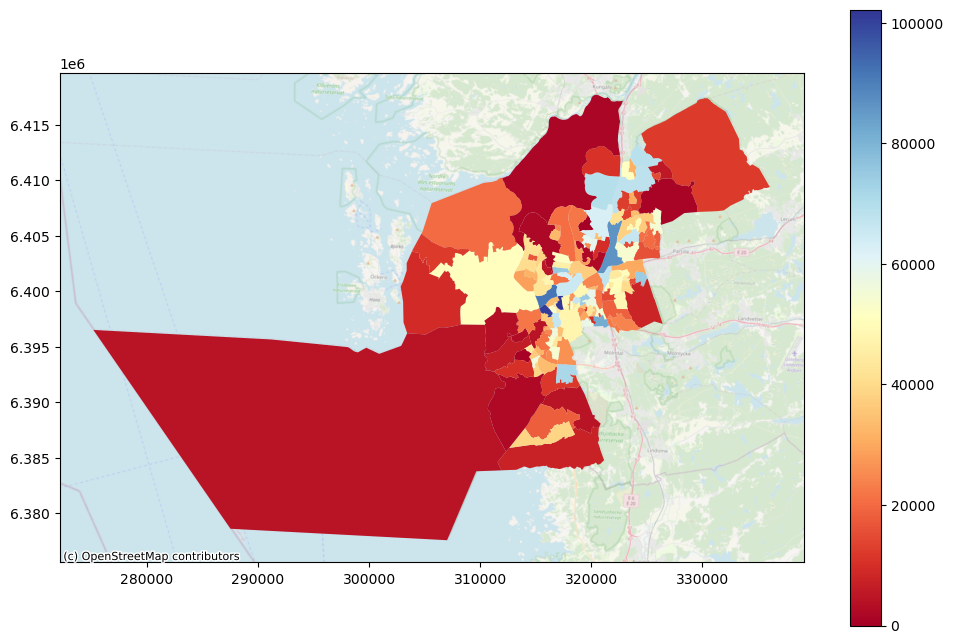

In [23]:
import contextily as cx
axes = regso_got_with_buildings.plot(
    column="Bostad;Flerfamiljshus_footprint",
    figsize=(12, 8),
    linewidth=1,
    cmap="RdYlBu",
    legend=True
    )
cx.add_basemap(axes, source=cx.providers.OpenStreetMap.Mapnik, 
               attribution=("(c) OpenStreetMap contributors"),
               crs=regso_got.crs, alpha=0.6, zoom=11)

<Axes: ylabel='Frequency'>

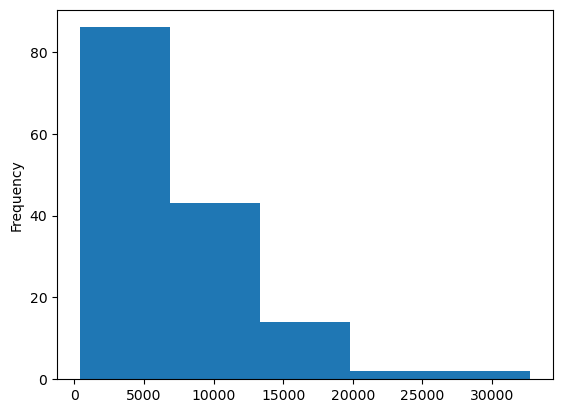

In [50]:
regso_got_with_buildings["Pop_Density"].plot.hist(bins=5)

## It is important to note that, while **regso_got_with_buildings.gpkg** have all the datasets, but they only have the geometry of the RegSO based on regsokod. In order to access the geometry for residential buildings, we can access **res_buildings_by_regso.gpkg**.